In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/dataset.csv")
df.head()

,TransactionID,Time,Account Number,Card Number,Transaction Type,Channel,Transaction Amount,Merchand Group,Country,Country 2,...,Gender,Bank,City,Merchand Code,Client Type,Account Type,Account Creation Date,Client ID,Accounts per Client,Has Multiple Accounts
0,MON2501012310248,2025-01-01 01:49:00,5101223942,4.650000e+15,PAIEMENT CARTE,WEB,1535.83,TELECOM,MA,MA,...,MALE,CDM,KENITRA,TEL_KEN_605,PPH,Checking,2019-04-22 01:49:00,165.0,1.0,False
1,MON2501027204531,2025-01-02 22:16:00,5101223942,4.650000e+15,PAIEMENT CARTE,MOBILE,288.04,PHARMACIE,MA,MA,...,MALE,CDM,KENITRA,PHA_KEN_868,PPH,Checking,2019-04-22 01:49:00,165.0,1.0,False
2,MON2501032430639,2025-01-03 01:19:00,5101223942,4.650000e+15,PAIEMENT CARTE,TPE,302.73,RESTAURATION,MA,MA,...,MALE,CDM,KENITRA,RES_KEN_829,PPH,Checking,2019-04-22 01:49:00,165.0,1.0,False
3,MON2501036325706,2025-01-03 09:56:00,5101223942,4.650000e+15,RETRAIT GAB,ATM,291.68,TELECOM,MA,MA,...,MALE,CDM,KENITRA,TEL_KEN_150,PPH,Checking,2019-04-22 01:49:00,165.0,1.0,False
4,MON2501031201899,2025-01-03 15:10:00,5101223942,4.650000e+15,RETRAIT GAB,ATM,594.52,LOISIRS,MA,MA,...,MALE,CDM,KENITRA,LOI_KEN_780,PPH,Checking,2019-04-22 01:49:00,165.0,1.0,False


In [4]:
df.columns

Index(['TransactionID', 'Time', 'Account Number', 'Card Number',
       'Transaction Type', 'Channel', 'Transaction Amount', 'Merchand Group',
       'Country', 'Country 2', 'City 2', 'Card Type', 'Age', 'Gender', 'Bank',
       'City', 'Merchand Code', 'Client Type', 'Account Type',
       'Account Creation Date', 'Client ID', 'Accounts per Client',
       'Has Multiple Accounts'],
      dtype='object')

In [3]:
df.shape

(1048575, 23)

In [ ]:
idcols=["TransactionID","Account Number","Card Number","Merchand Code","Client ID"]

In [ ]:
numcols=["Transaction Amount","Age",]

In [53]:
catcols=["Transaction Type","Channel","Card Type","Gender","Merchand Group","Country","City","Country 2","City 2"]

In [54]:
df.dropna(inplace=True)

In [55]:
df['Time']=pd.to_datetime(df['Time'])
df['Age']=df['Age'].astype(int)

In [56]:
df['hour']=df['Time'].dt.hour
df['date']=df['Time'].dt.date
df['LogAmount']=np.log(df['Transaction Amount'])

In [57]:
sampledf=df.sample(n=100000,random_state=42)
# sampledf.to_csv("sampledata.csv")

# Univariate Analysis

In [58]:
#Numeric Features
df[['Age','Transaction Amount',"LogAmount"]].describe()

,Age,Transaction Amount,LogAmount
count,1.100000e+06,1.100000e+06,1.100000e+06
mean,4.534759e+01,7.509476e+02,5.927495e+00
std,1.559179e+01,1.321570e+03,1.164012e+00
min,1.900000e+01,1.940000e+00,6.626880e-01
25%,3.200000e+01,1.700400e+02,5.136034e+00
50%,4.500000e+01,3.697000e+02,5.912692e+00
75%,5.900000e+01,8.166400e+02,6.705198e+00
max,7.200000e+01,8.947838e+04,1.140175e+01


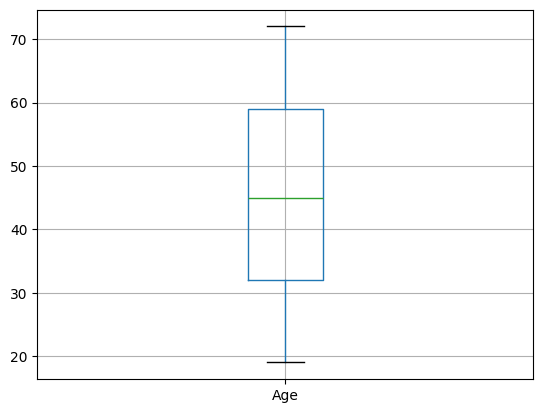

In [59]:
sampledf.boxplot("Age")
plt.show()

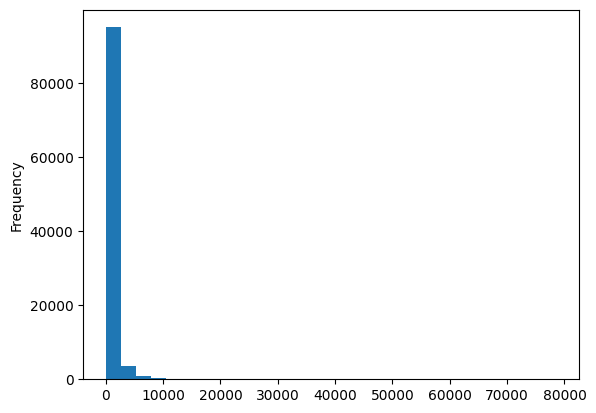

In [60]:
sampledf['Transaction Amount'].plot(kind='hist',bins=30)
plt.show()

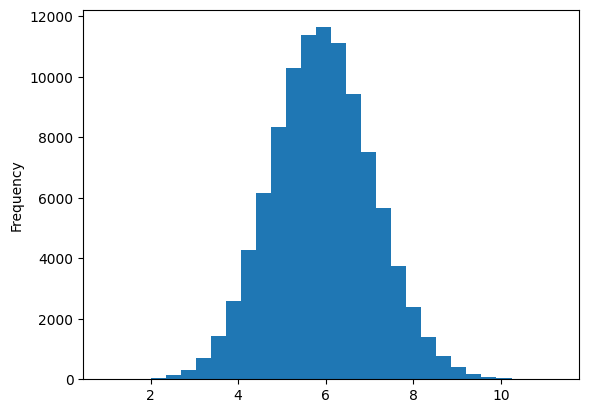

In [61]:
sampledf['LogAmount'].plot(kind='hist',bins=30)
plt.show()

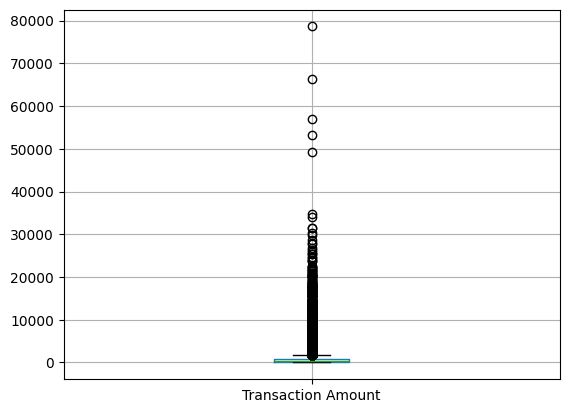

In [62]:
sampledf.boxplot("Transaction Amount")
plt.show()

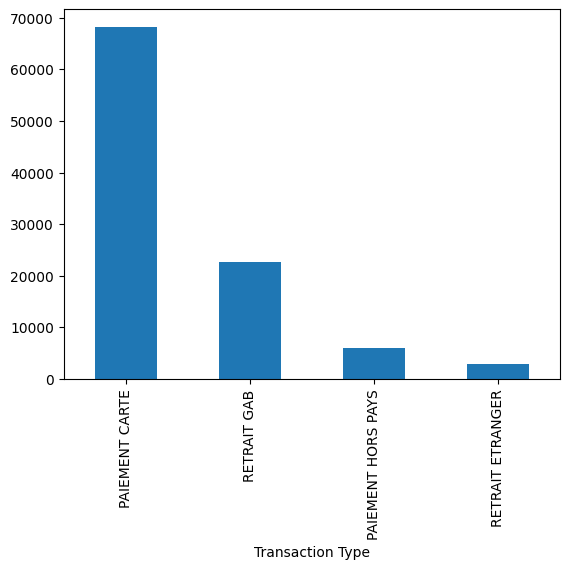

In [63]:
#Categorical Features
sampledf['Transaction Type'].value_counts().plot(kind='bar')
plt.show()

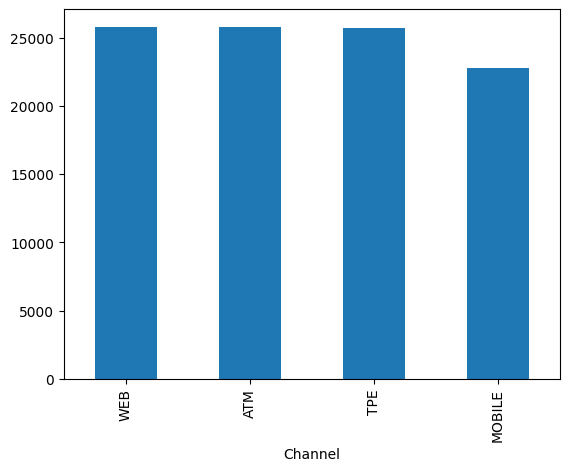

In [64]:
sampledf['Channel'].value_counts().plot(kind='bar')
plt.show()

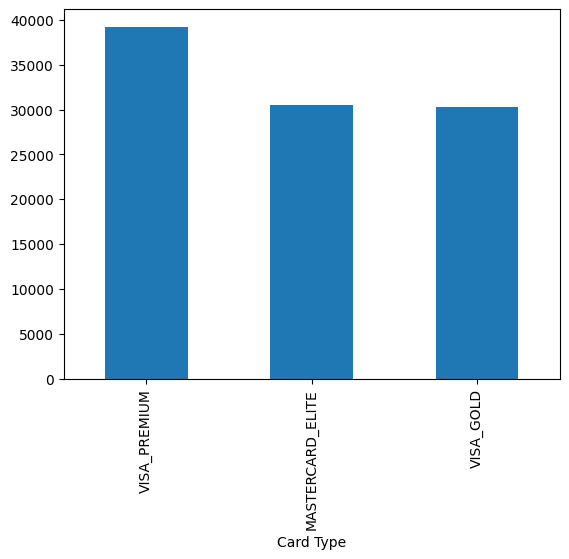

In [65]:
sampledf['Card Type'].value_counts().plot(kind='bar')
plt.show()

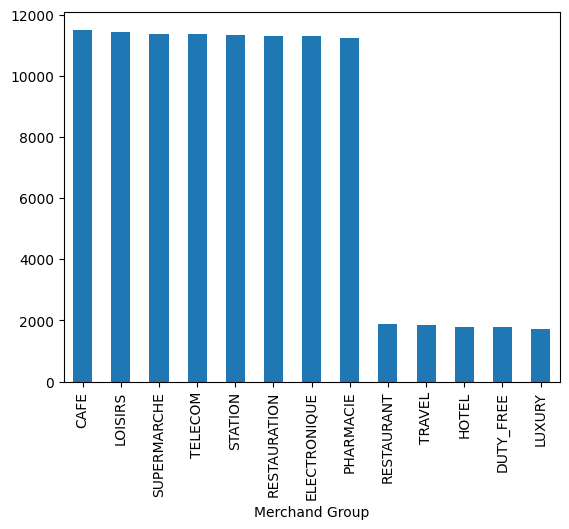

In [66]:
sampledf['Merchand Group'].value_counts().plot(kind='bar')
plt.show()

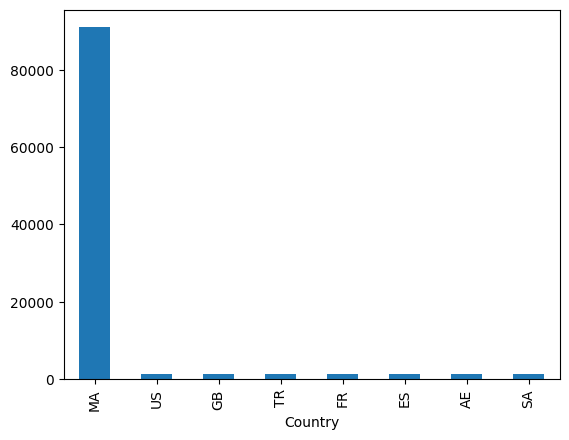

In [67]:
sampledf['Country'].value_counts().plot(kind='bar')
plt.show()

# Client Behavior Analysis

In [68]:
#sampling different type of clients to analyze normal behavior
activity=df.groupby("Account Number").size()
cltactivity=activity.to_frame("activity")
cltactivity["bucket"]=pd.qcut(
    cltactivity['activity'],
    q=[0,0.33,0.66,1],
    labels=['low','medium','high']
)

In [69]:
sampledclt=cltactivity.groupby("bucket",group_keys=False).apply(lambda x: x.sample(n=min(len(x),5),random_state=42))
sampledclt=sampledclt.index

sampledf=df[df['Account Number'].isin(sampledclt)]
sampledf.shape

(8729, 20)

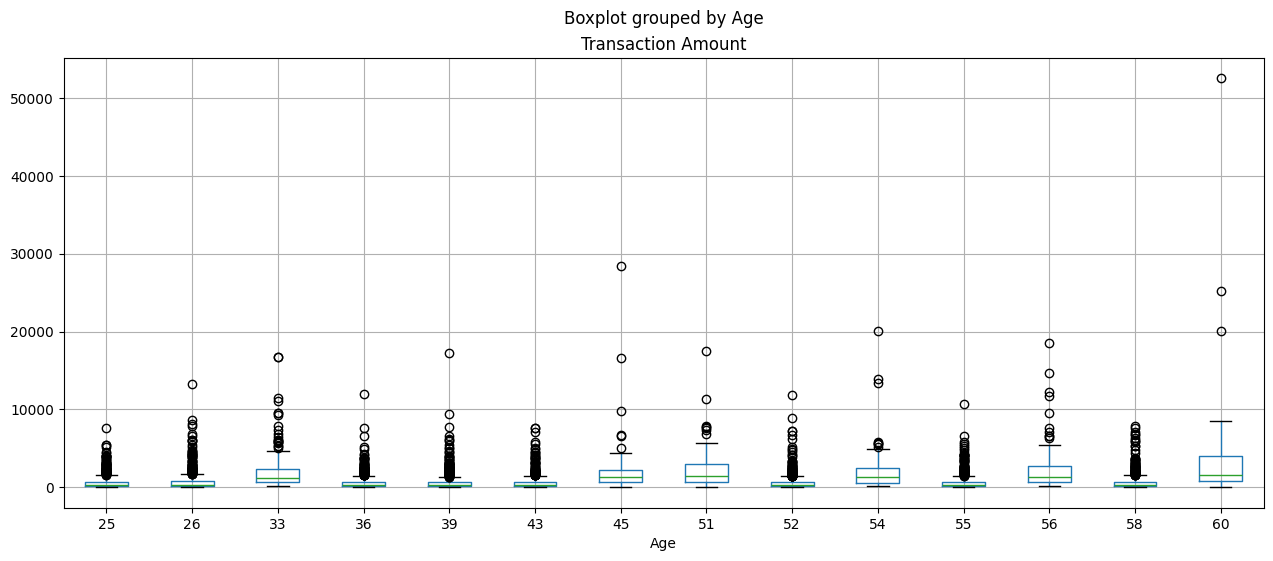

In [70]:
sampledf.boxplot("Transaction Amount",by='Age',figsize=(15,6))
plt.show()

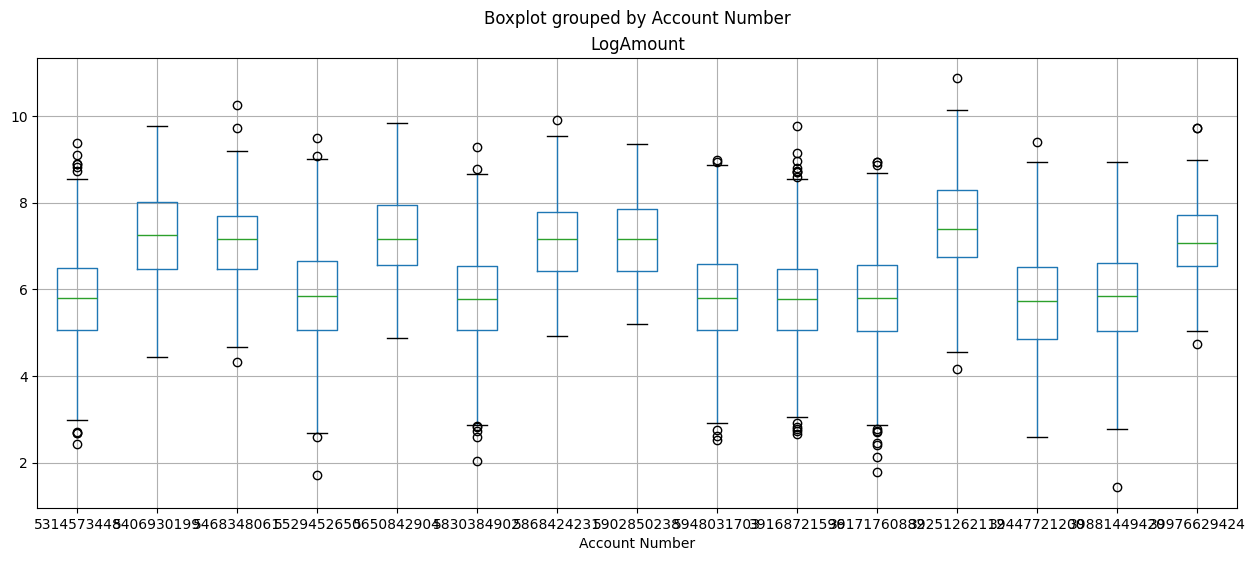

In [71]:
sampledf.boxplot("LogAmount",by='Account Number',figsize=(15,6))
plt.show()

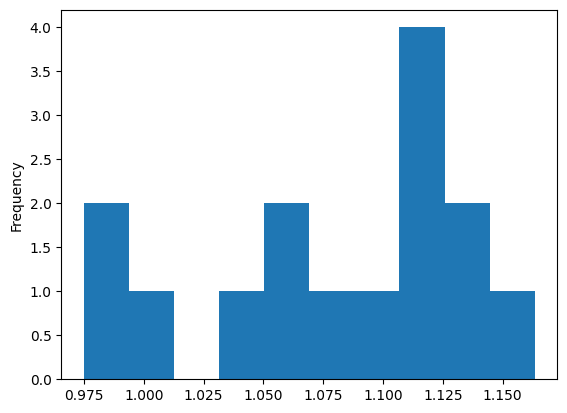

In [72]:
cltstats=sampledf.groupby("Account Number").agg({"LogAmount":['count','mean','std'],
                                        "Transaction Amount":['count','mean','std']})

cltstats[("LogAmount","std")].plot(kind='hist')
plt.show()

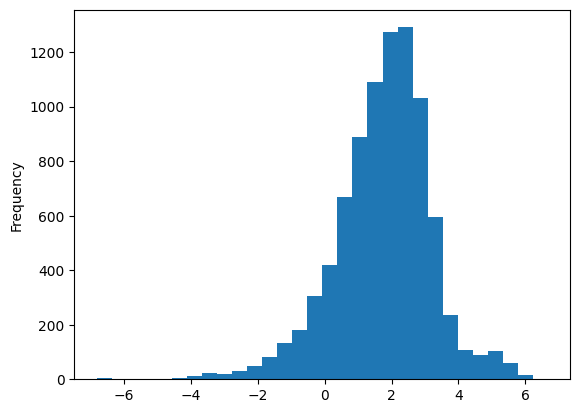

In [73]:
timedf=sampledf[['Time','date','Account Number','Transaction Amount','LogAmount']].sort_values(['Account Number','Time'])
timedf['TimeDiff']=timedf.groupby("Account Number")['Time'].diff().dt.total_seconds()/3600
timedf['LogTimeDiff']=np.log(timedf['TimeDiff'])
timedf['LogTimeDiff'].plot(kind='hist',bins=30)
plt.show()


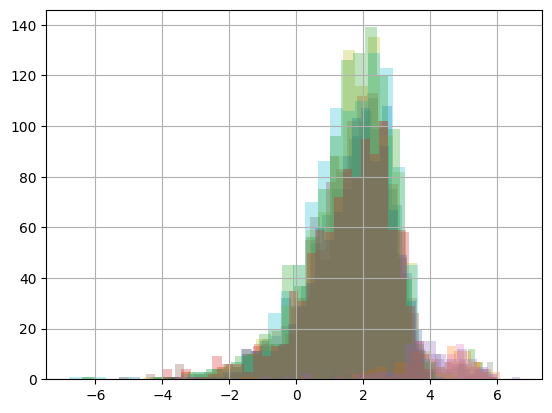

In [74]:
for acc, dfacc in timedf.groupby("Account Number"):
    dfacc['LogTimeDiff'].hist(bins=30,alpha=0.3)

plt.show()

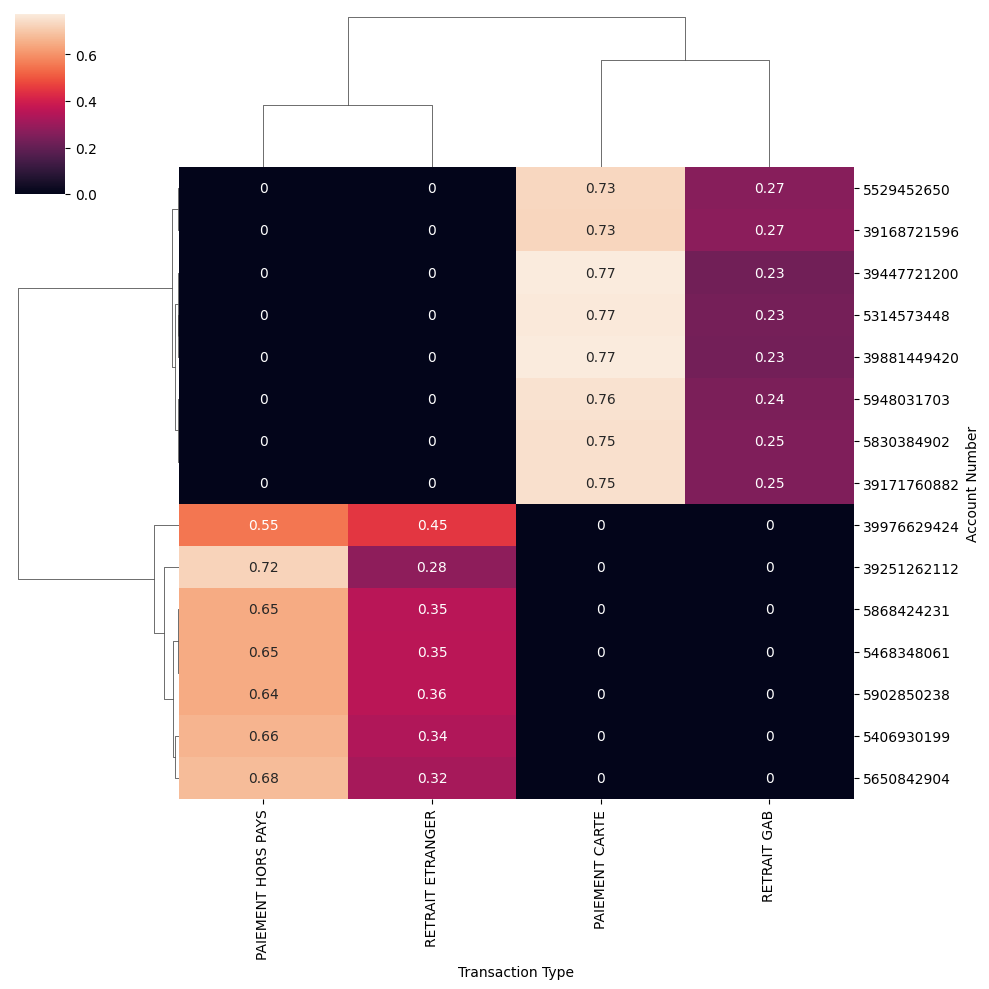

In [75]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Transaction Type']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

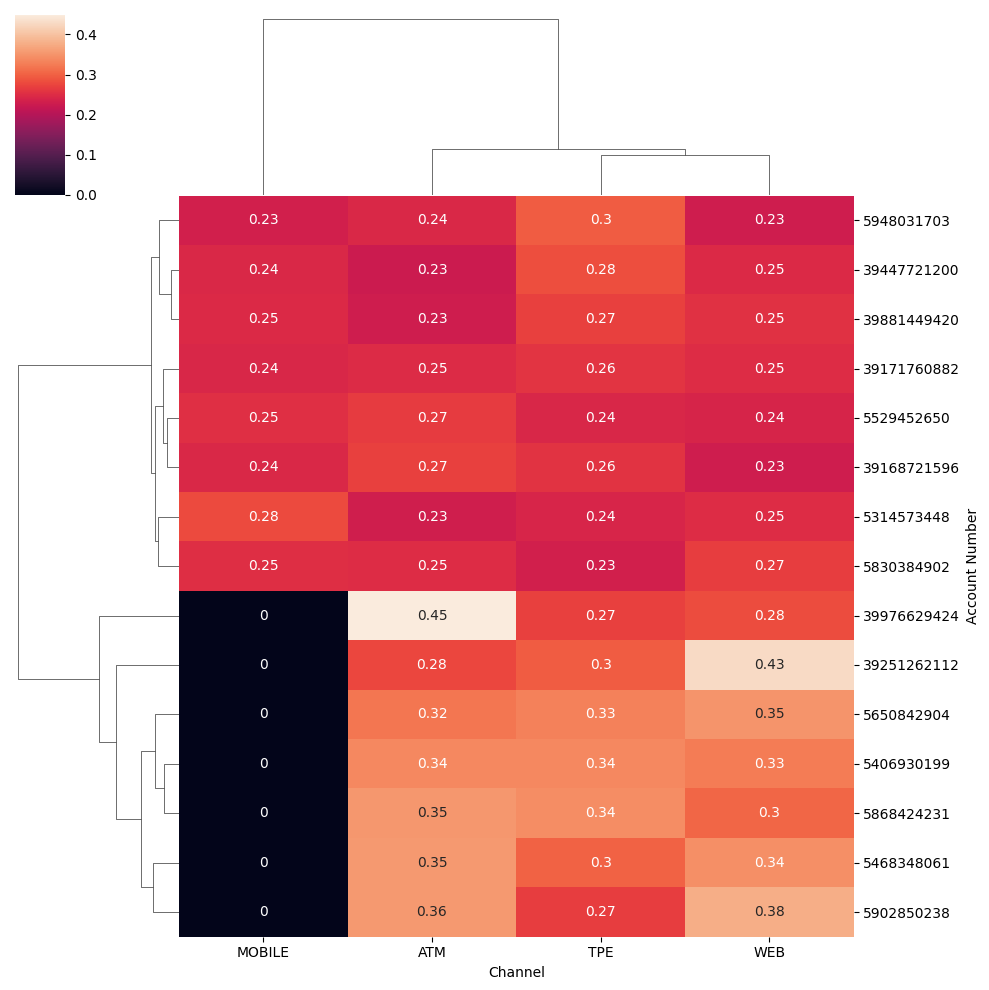

In [76]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Channel']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

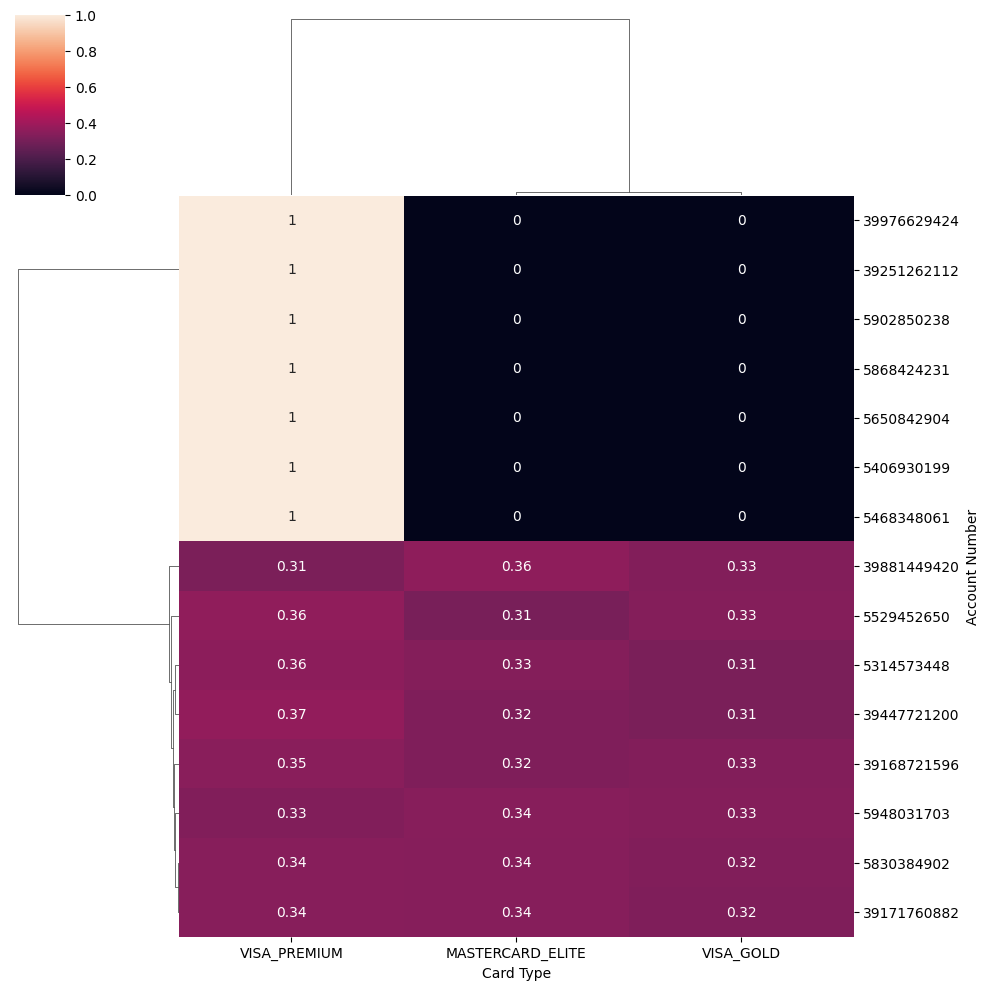

In [77]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Card Type']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

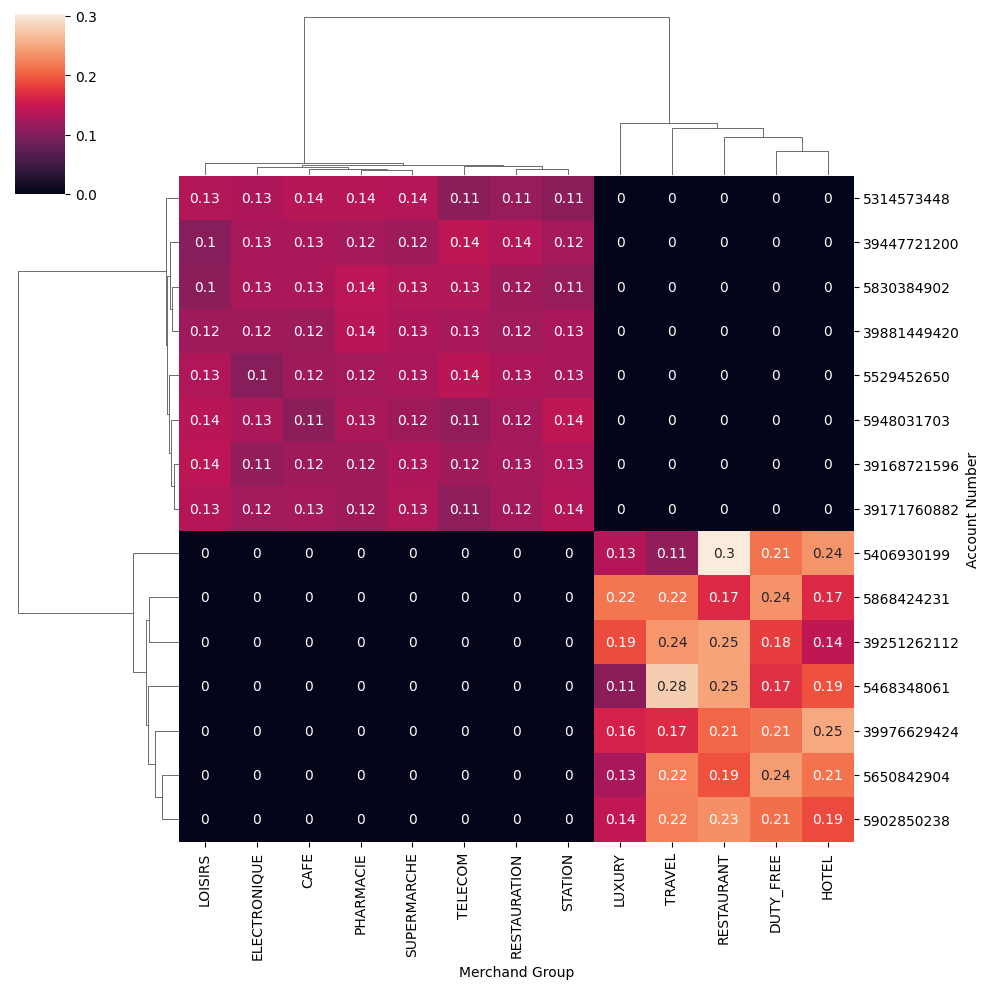

In [78]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Merchand Group']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

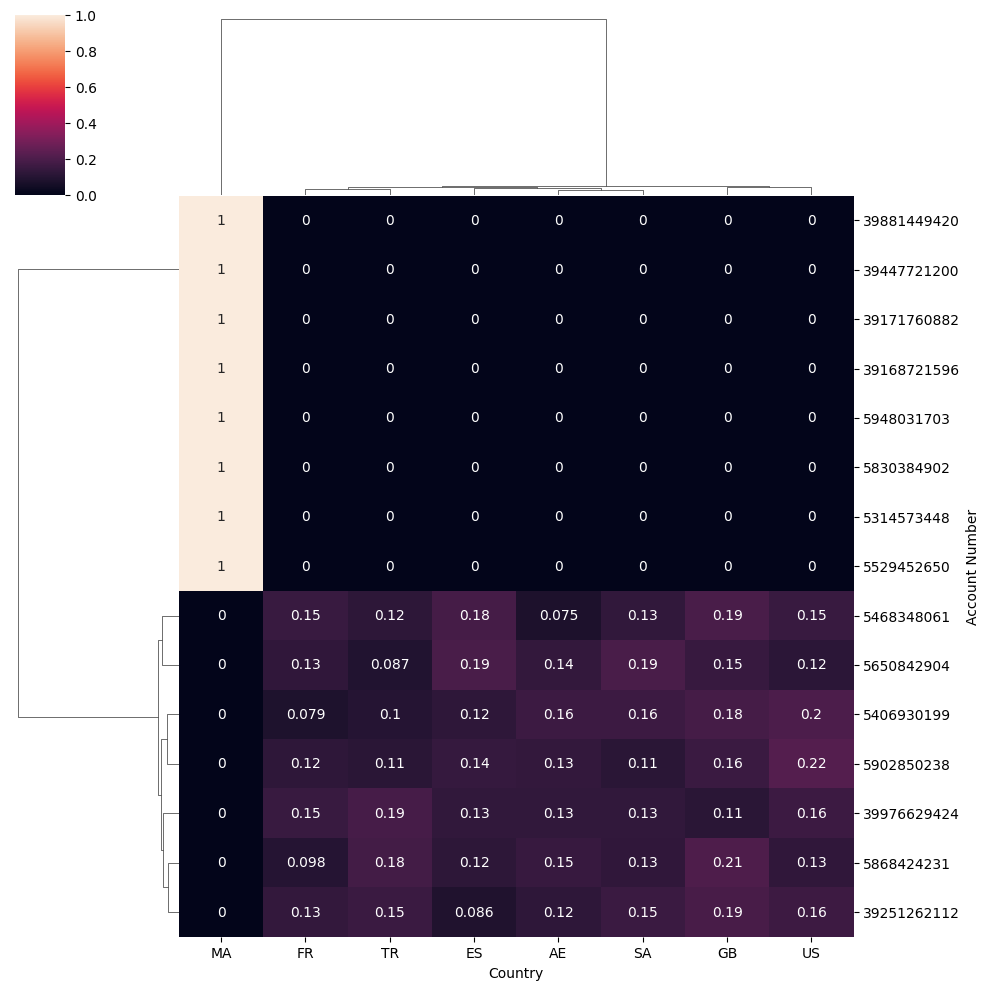

In [79]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Country']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

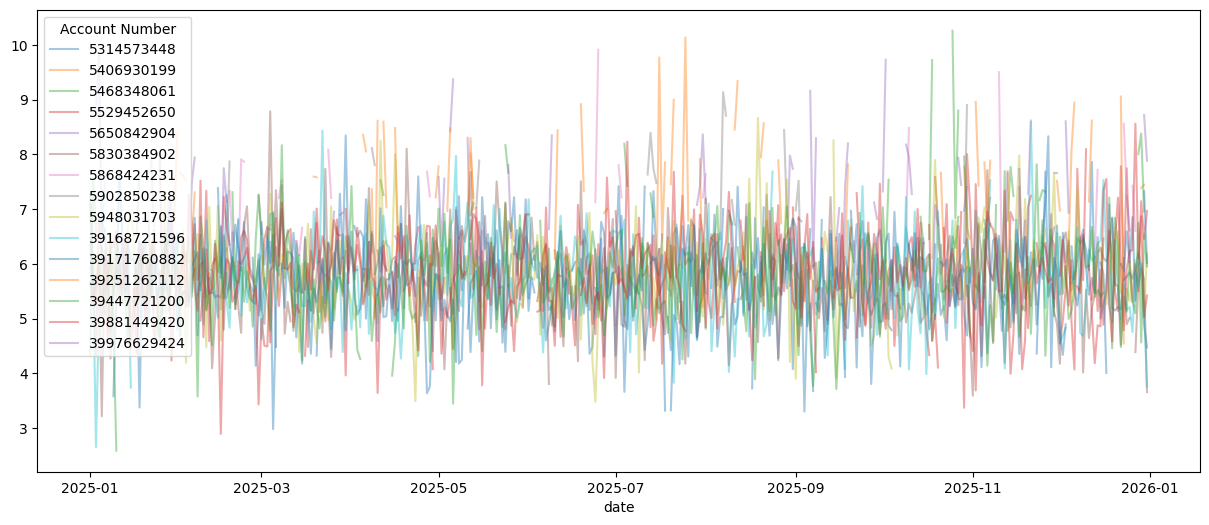

In [80]:
daily = sampledf.groupby(["Account Number", "date"])["LogAmount"].mean().reset_index()

pivot_daily = daily.pivot(index="date", columns="Account Number", values="LogAmount")

pivot_daily.plot(figsize=(15,6),alpha=0.4)
plt.show()

# Feature Engineering

In [81]:
df.sort_values(['Account Number','Time'],inplace=True)
df['MovingAvg']=df['LogAmount'].rolling(window=7).mean()
df['MovingAvg']=df['LogAmount'].rolling(window=7).std()

In [82]:
df['TimeDiff']=df.groupby("Account Number")['Time'].diff().dt.total_seconds()/3600
df['LogTimeDiff']=np.log(df['TimeDiff'])

c:\Projects\RealTimeFraudDetection\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [83]:
def entropy(series):
    p=series.value_counts(normalize=True)
    return -(p * np.log(p)).sum()

In [94]:
def normalentropy(series):
    p=series.value_counts(normalize=True)
    h=-(p*np.log(p)).sum()
    return h/np.log(len(p)) if len(p) > 1 else 0

In [95]:
transactiontypeentropy=df.groupby("Account Number")['Transaction Type'].apply( normalentropy ).reset_index(name="TransactionTypeEntropy")
channelentropy=df.groupby("Account Number")['Channel'].apply( normalentropy ).reset_index(name="ChannelEntropy")
cardtypeentropy=df.groupby("Account Number")['Card Type'].apply( normalentropy ).reset_index(name="CardTypeEntropy")
merchandentropy=df.groupby("Account Number")['Merchand Group'].apply( normalentropy ).reset_index(name="MerchandEntropy")
countryentropy=df.groupby("Account Number")['Country'].apply( normalentropy ).reset_index(name="CountryEntropy")
cityentropy=df.groupby("Account Number")['City'].apply( normalentropy ).reset_index(name="CityEntropy")

In [97]:
finaldf=df.merge(transactiontypeentropy,on='Account Number',how='left')
finaldf=finaldf.merge(channelentropy,on='Account Number',how='left')
finaldf=finaldf.merge(cardtypeentropy,on='Account Number',how='left')
finaldf=finaldf.merge(merchandentropy,on='Account Number',how='left')
finaldf=finaldf.merge(countryentropy,on='Account Number',how='left')
finaldf=finaldf.merge(cityentropy,on='Account Number',how='left')